In [ ]:
# Adapted from https://github.com/facebookresearch/segment-anything/blob/main/notebooks/automatic_mask_generator_example.ipynb

# Automatically generating object masks with SAM

Since SAM 2 can efficiently process prompts, masks for the entire image can be generated by sampling a large number of prompts over an image.

The class `SAM2AutomaticMaskGenerator` implements this capability. It works by sampling single-point input prompts in a grid over the image, from each of which SAM can predict multiple masks. Then, masks are filtered for quality and deduplicated using non-maximal suppression. Additional options allow for further improvement of mask quality and quantity, such as running prediction on multiple crops of the image or postprocessing masks to remove small disconnected regions and holes.

<a target="_blank" href="https://colab.research.google.com/github/facebookresearch/sam2/blob/main/notebooks/automatic_mask_generator_example.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

## Environment Set-up

If running locally using jupyter, first install `SAM 2` in your environment using the installation instructions in the repository.

If running from Google Colab, set `using_colab=True` below and run the cell. In Colab, be sure to select 'GPU' under 'Edit'->'Notebook Settings'->'Hardware accelerator'. Note that it's recommended to use **A100 or L4 GPUs when running in Colab** (T4 GPUs might also work, but could be slow and might run out of memory in some cases).

In [2]:
using_colab = True

In [3]:
if using_colab:
    import torch
    import torchvision
    print("PyTorch version:", torch.__version__)
    print("Torchvision version:", torchvision.__version__)
    print("CUDA is available:", torch.cuda.is_available())
    import sys
    !{sys.executable} -m pip install opencv-python matplotlib
    !{sys.executable} -m pip install 'git+https://github.com/facebookresearch/sam2.git'

    !mkdir -p images
    !wget -P images https://raw.githubusercontent.com/facebookresearch/sam2/main/notebooks/images/cars.jpg

    !mkdir -p ../checkpoints/
    !wget -P ../checkpoints/ https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_large.pt

PyTorch version: 2.9.0+cu126
Torchvision version: 0.24.0+cu126
CUDA is available: True
  Cloning https://github.com/facebookresearch/sam2.git to /tmp/pip-req-build-kxytub06
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/sam2.git /tmp/pip-req-build-kxytub06
  Resolved https://github.com/facebookresearch/sam2.git to commit 2b90b9f5ceec907a1c18123530e92e794ad901a4
  Installing build dependencies ... canceled
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 377, in run
    requirement_set = resolver.resolve(
                   

## Set-up

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
# if using Apple MPS, fall back to CPU for unsupported ops
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
# select the device for computation
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"using device: {device}")

if device.type == "cuda":
    # use bfloat16 for the entire notebook
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    # turn on tfloat32 for Ampere GPUs (https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices)
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
elif device.type == "mps":
    print(
        "\nSupport for MPS devices is preliminary. SAM 2 is trained with CUDA and might "
        "give numerically different outputs and sometimes degraded performance on MPS. "
        "See e.g. https://github.com/pytorch/pytorch/issues/84936 for a discussion."
    )

using device: cuda


/usr/local/lib/python3.12/dist-packages/torch/backends/__init__.py:46: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  self.setter(val)


In [ ]:
np.random.seed(3)

def show_anns(anns, borders=True):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:, :, 3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.5]])
        img[m] = color_mask
        if borders:
            import cv2
            contours, _ = cv2.findContours(m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
            # Try to smooth contours
            contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
            cv2.drawContours(img, contours, -1, (0, 0, 1, 0.4), thickness=1)

    ax.imshow(img)

## Example image

In [ ]:
image = Image.open('images/floorplan6.png')
image = np.array(image.convert("RGB"))
print("SAM image shape:", image.shape)

SAM image shape: (1688, 2052, 3)


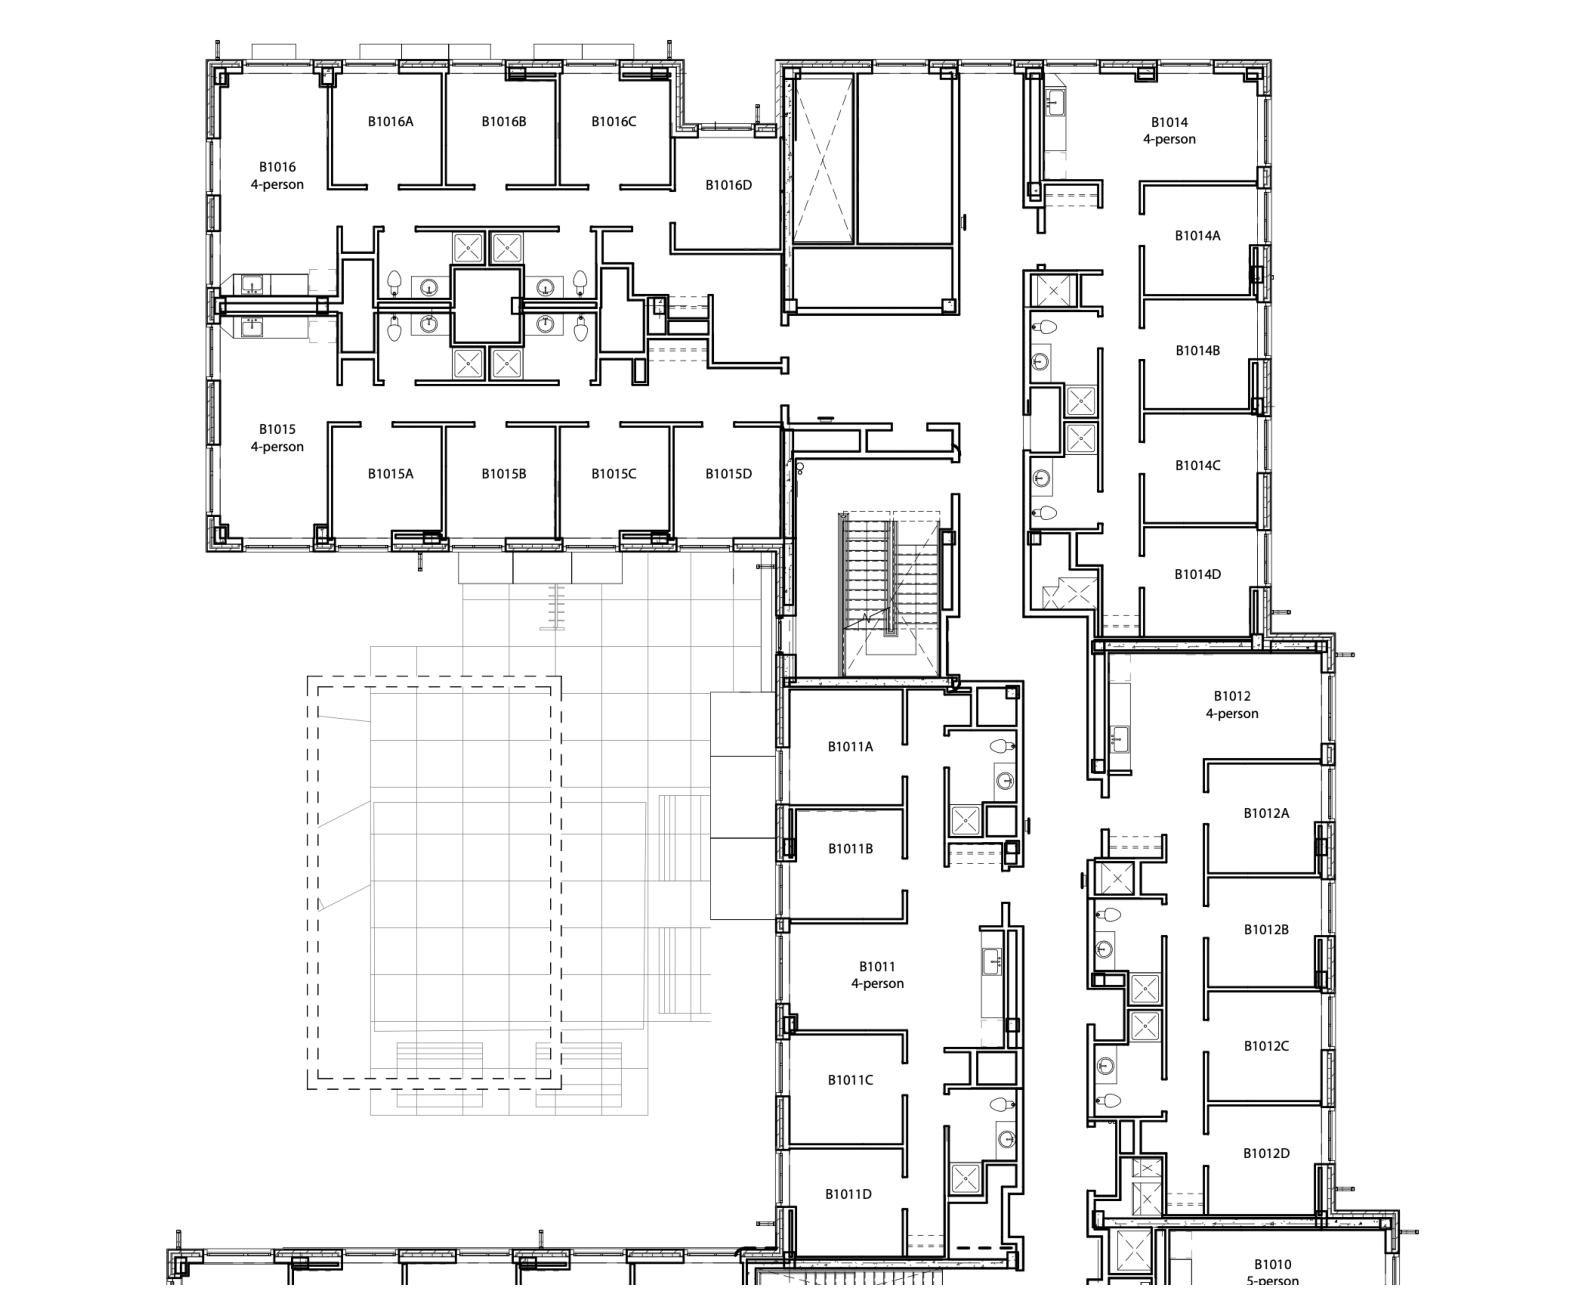

In [ ]:
plt.figure(figsize=(20, 20))
plt.imshow(image)
plt.axis('off')
plt.show()

## Automatic mask generation

To run automatic mask generation, provide a version of SAM 2 to the `SAM2AutomaticMaskGenerator` class. Set the path below to the SAM 2 checkpoint.

In [ ]:
from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

sam2_checkpoint = "../checkpoints/sam2.1_hiera_large.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"

sam2 = build_sam2(model_cfg, sam2_checkpoint, device=device, apply_postprocessing=False)

mask_generator = SAM2AutomaticMaskGenerator(sam2)

To generate masks, just run `generate` on an image.

In [ ]:
masks = mask_generator.generate(image)

Mask generation returns a list over masks, where each mask is a dictionary containing various data about the mask. These keys are:
* `segmentation` : the mask
* `area` : the area of the mask in pixels
* `bbox` : the boundary box of the mask in XYWH format
* `predicted_iou` : the model's own prediction for the quality of the mask
* `point_coords` : the sampled input point that generated this mask
* `stability_score` : an additional measure of mask quality
* `crop_box` : the crop of the image used to generate this mask in XYWH format

In [ ]:
print(len(masks))
print(masks[0].keys())

30
dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])


Show all the masks overlayed on the image.

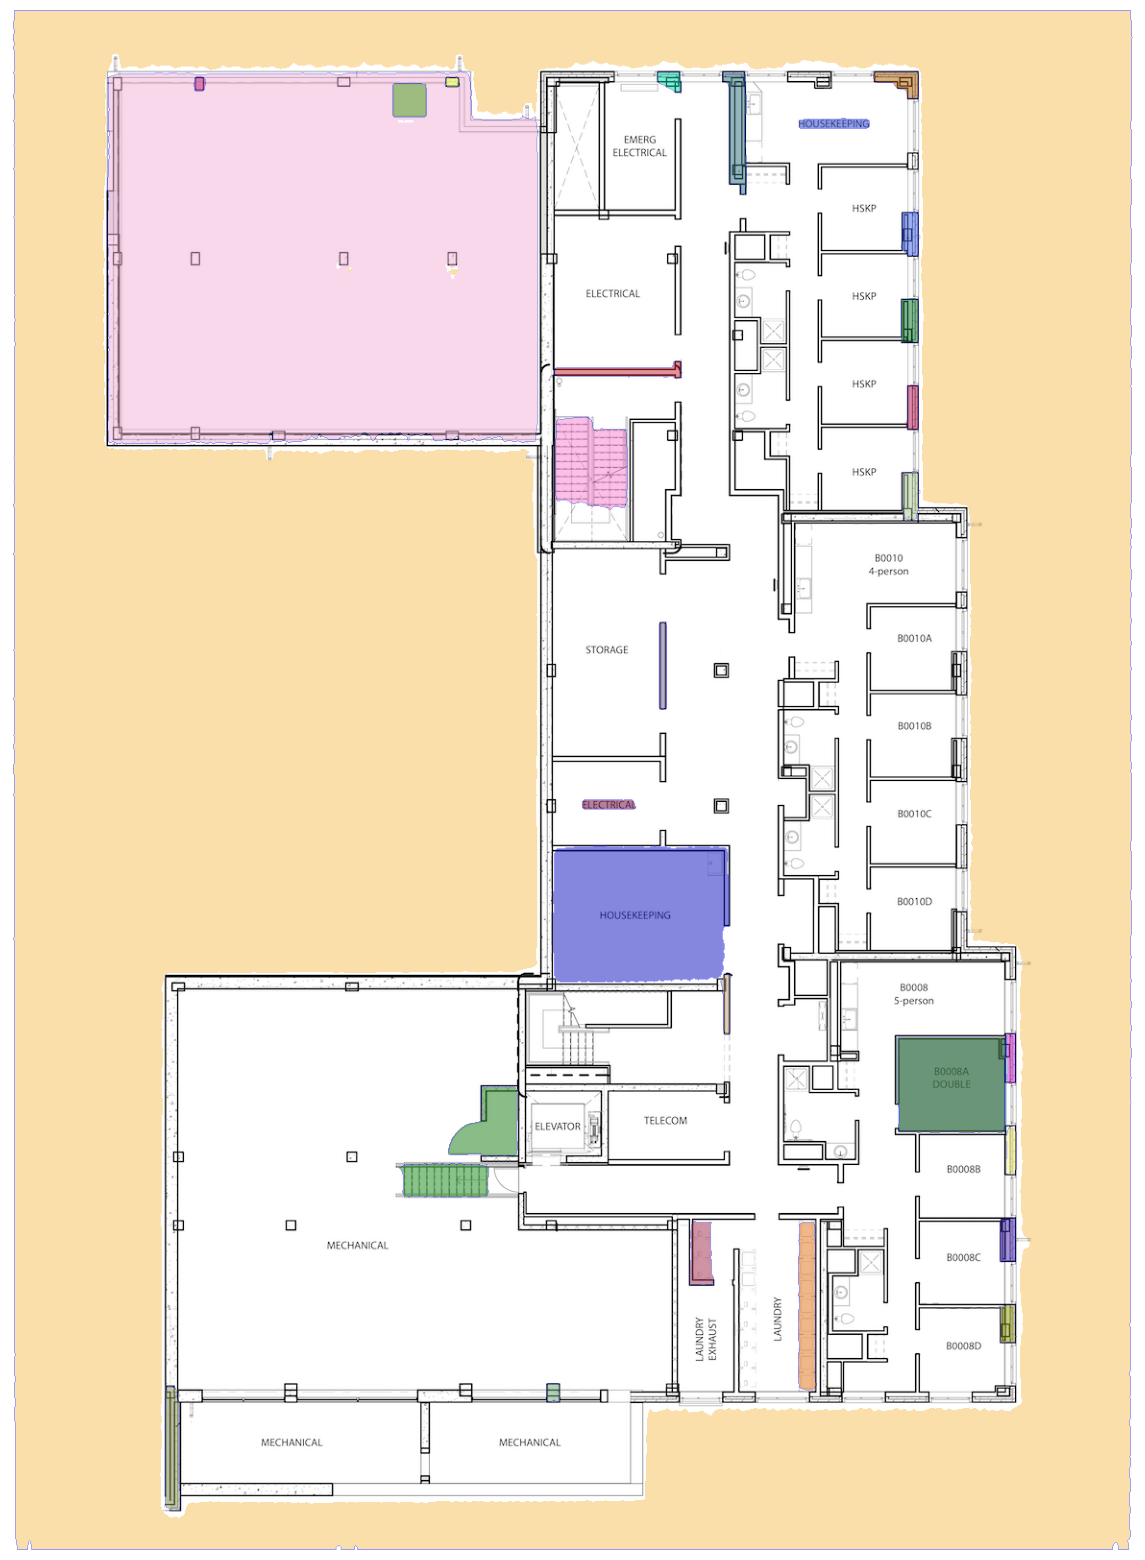

In [ ]:
plt.figure(figsize=(20, 20))
plt.imshow(image)
show_anns(masks)
plt.axis('off')
plt.show()

## Automatic mask generation options

There are several tunable parameters in automatic mask generation that control how densely points are sampled and what the thresholds are for removing low quality or duplicate masks. Additionally, generation can be automatically run on crops of the image to get improved performance on smaller objects, and post-processing can remove stray pixels and holes. Here is an example configuration that samples more masks:

In [ ]:
mask_generator_2 = SAM2AutomaticMaskGenerator(
    model=sam2,
    points_per_side=64,
    points_per_batch=128,
    pred_iou_thresh=0.85,
    stability_score_thresh=0.92,
    stability_score_offset=0.7,
    crop_n_layers=1,
    box_nms_thresh=0.7,
    crop_n_points_downscale_factor=2,
    min_mask_region_area=25.0,
    use_m2m=True,
)

In [ ]:
mask_generator_2_updated = SAM2AutomaticMaskGenerator(
    model=sam2,
    points_per_side=96,  # Increased sampling density
    points_per_batch=128,
    pred_iou_thresh=0.80, # Lowered threshold for predicted IoU
    stability_score_thresh=0.85, # Lowered threshold for stability score
    stability_score_offset=0.7,
    crop_n_layers=1,
    box_nms_thresh=0.7,
    crop_n_points_downscale_factor=2,
    min_mask_region_area=25.0,
    use_m2m=True,
)


In [ ]:
masks2_updated = mask_generator_2.generate(image)
print(f"Generated {len(masks2_updated)} masks with updated parameters.")


Generated 267 masks with updated parameters.


In [ ]:
MAX_W = 500   # max width in pixels
MAX_H = 200
MIN_H = 100

filtered_masks=[]
for m in masks2_updated:
    x,y,w,h = m["bbox"]
    if w <= MAX_W and MIN_H <= h <= MAX_H:
        filtered_masks.append(m)

MAX_ROOM_AREA = 30000
MIN_ROOM_AREA = 11000
filtered_masks = [m for m in filtered_masks if m["area"] <= MAX_ROOM_AREA and m["area"] >= MIN_ROOM_AREA]

print({len(filtered_masks)})

{17}


In [ ]:
import pickle

out_path = "filtered_masks.pkl"
with open(out_path, "wb") as f:
    pickle.dump(filtered_masks, f, protocol=pickle.HIGHEST_PROTOCOL)

print("Saved", len(filtered_masks), "masks ->", out_path)


Saved 17 masks -> filtered_masks.pkl


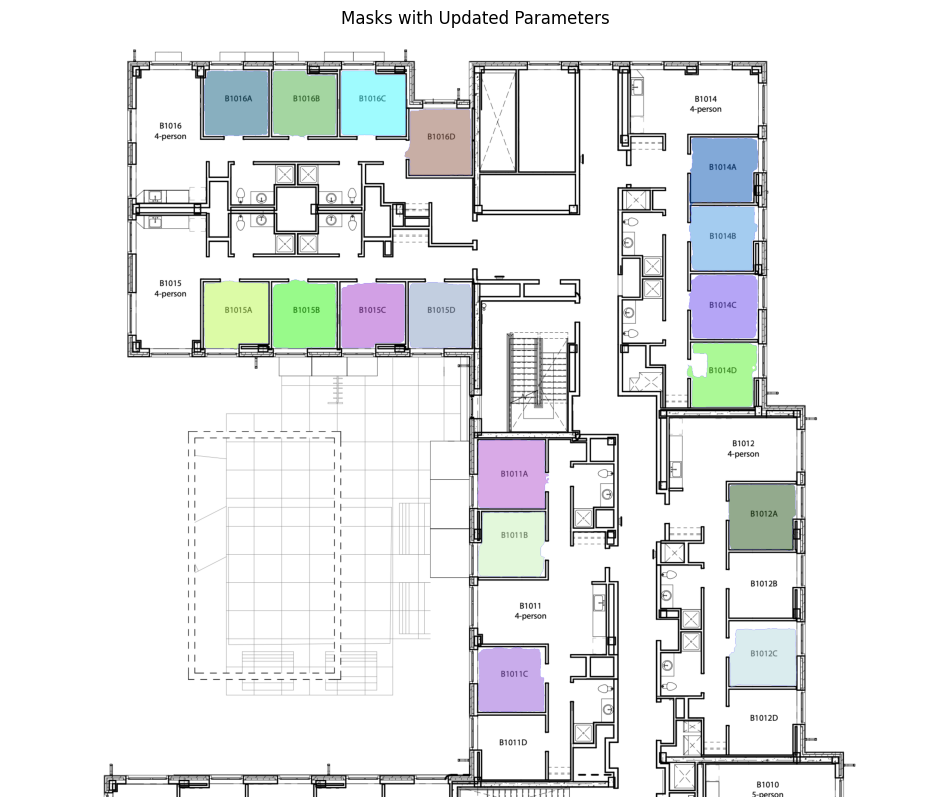

In [ ]:
plt.figure(figsize=(12, 12))
plt.imshow(image)
show_anns(filtered_masks)
plt.axis('off')
plt.title('Masks with Updated Parameters')
plt.show()

In [ ]:
# --- masks_notebook_export.py ---
import numpy as np
import pickle
import json
from pathlib import Path

out_dir = Path(".")
out_pkl = out_dir / "filtered_masks.pkl"
out_meta = out_dir / "filtered_masks_meta.json"

# Basic on-screen diagnostics
print("Number of filtered_masks:", len(filtered_masks))
for i, m in enumerate(filtered_masks[:10]):
    seg = m.get('segmentation')
    seg = np.asarray(seg) if seg is not None else None
    print(f"mask[{i}] shape:", None if seg is None else seg.shape,
          "bbox(meta):", m.get('bbox'),
          "area(meta):", m.get('area'))

# Option 1 (quick): pickle (fast, preserves Python objects)
with open(out_pkl, "wb") as f:
    pickle.dump(filtered_masks, f, protocol=pickle.HIGHEST_PROTOCOL)
print("Wrote pickle ->", out_pkl)


Number of filtered_masks: 17
mask[0] shape: (1688, 2052) bbox(meta): [578.0, 87.0, 141.0, 149.0] area(meta): 19434
mask[1] shape: (1688, 2052) bbox(meta): [730.0, 86.0, 143.0, 144.0] area(meta): 19947
mask[2] shape: (1688, 2052) bbox(meta): [428.0, 87.0, 141.0, 144.0] area(meta): 20014
mask[3] shape: (1688, 2052) bbox(meta): [870.0, 171.0, 148.0, 148.0] area(meta): 20015
mask[4] shape: (1688, 2052) bbox(meta): [578.0, 547.0, 141.0, 152.0] area(meta): 20207
mask[5] shape: (1688, 2052) bbox(meta): [730.0, 554.0, 140.0, 145.0] area(meta): 19067
mask[6] shape: (1688, 2052) bbox(meta): [881.0, 553.0, 137.0, 146.0] area(meta): 19481
mask[7] shape: (1688, 2052) bbox(meta): [427.0, 549.0, 143.0, 153.0] area(meta): 20273
mask[8] shape: (1688, 2052) bbox(meta): [1032.0, 1057.0, 148.0, 146.0] area(meta): 20154
mask[9] shape: (1688, 2052) bbox(meta): [1033.0, 1357.0, 146.0, 143.0] area(meta): 19785
Wrote pickle -> filtered_masks.pkl
